<a href="https://colab.research.google.com/github/Hkd225/Animals10-full-classification-mobilenetv2/blob/main/10_Animal_mobilenetv2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q tensorflow kagglehub split-folders scikit-learn seaborn

import os
import random
import shutil
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub
import splitfolders
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.utils import load_img, img_to_array
from google.colab import files as colab_files

print("TensorFlow version:", tf.__version__)

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

TensorFlow version: 2.19.0


In [ ]:
# 1. TRANSLATE LABEL

it_to_en = {
    "cane": "dog",
    "cavallo": "horse",
    "elefante": "elephant",
    "farfalla": "butterfly",
    "gallina": "chicken",
    "gatto": "cat",
    "mucca": "cow",
    "pecora": "sheep",
    "ragno": "spider",
    "scoiattolo": "squirrel",
}

en_to_it = {v: k for k, v in it_to_en.items()}

translate = {}
translate.update(it_to_en)
translate.update(en_to_it)


In [ ]:
# 2. PATH COLAB

WORKING_DIR = os.getcwd()
SUBMISSION_DIR = os.path.join(WORKING_DIR, "submission")
SPLIT_DIR = os.path.join(WORKING_DIR, "animals10_split")
FILTERED_SOURCE_DIR = os.path.join(WORKING_DIR, "animals10_all")

for folder in [SUBMISSION_DIR, SPLIT_DIR, FILTERED_SOURCE_DIR]:
    if os.path.exists(folder):
        shutil.rmtree(folder)

os.makedirs(SUBMISSION_DIR, exist_ok=True)
os.makedirs(FILTERED_SOURCE_DIR, exist_ok=True)

# 3. DOWNLOAD DATASET ANIMALS-10

path = kagglehub.dataset_download("alessiocorrado99/animals10")
print("Path dataset:", path)
print("Isi root:", os.listdir(path))

RAW_SOURCE_DIR = os.path.join(path, "raw-img")
if not os.path.exists(RAW_SOURCE_DIR):
    raise FileNotFoundError(f"Folder raw-img tidak ditemukan di: {RAW_SOURCE_DIR}")

print("Folder dataset:", RAW_SOURCE_DIR)
print("Class folders:", sorted(os.listdir(RAW_SOURCE_DIR)))


# 4. PAKAI SEMUA CLASS

ALL_CLASSES = sorted([
    d for d in os.listdir(RAW_SOURCE_DIR)
    if os.path.isdir(os.path.join(RAW_SOURCE_DIR, d))
])

print("Semua class terdeteksi:", ALL_CLASSES)

for class_name in ALL_CLASSES:
    src = os.path.join(RAW_SOURCE_DIR, class_name)
    dst = os.path.join(FILTERED_SOURCE_DIR, class_name)
    shutil.copytree(src, dst)

print("Jumlah class:", len(ALL_CLASSES))
print("Isi filtered folder:", sorted(os.listdir(FILTERED_SOURCE_DIR)))


# 5. split dataset
splitfolders.ratio(
    FILTERED_SOURCE_DIR,
    output=SPLIT_DIR,
    seed=SEED,
    ratio=(0.8, 0.1, 0.1)
)

TRAIN_DIR = os.path.join(SPLIT_DIR, "train")
VAL_DIR = os.path.join(SPLIT_DIR, "val")
TEST_DIR = os.path.join(SPLIT_DIR, "test")

print("Train directory:", TRAIN_DIR)
print("Val directory:", VAL_DIR)
print("Test directory:", TEST_DIR)


# 6. LOAD DATASET

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_ds_raw = image_dataset_from_directory(
    TRAIN_DIR,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds_raw = image_dataset_from_directory(
    VAL_DIR,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds_raw = image_dataset_from_directory(
    TEST_DIR,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds_raw.class_names
num_classes = len(class_names)
class_names_en = [translate.get(c, c) for c in class_names]

print("Class names (IT):", class_names)
print("Class names (EN):", class_names_en)
print("Number of classes:", num_classes)

def count_images(folder):
    total = 0
    for root, dirs, files in os.walk(folder):
        total += len([f for f in files if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))])
    return total

train_count = count_images(TRAIN_DIR)
val_count = count_images(VAL_DIR)
test_count = count_images(TEST_DIR)

print("Train images:", train_count)
print("Val images:", val_count)
print("Test images:", test_count)
print("Total images:", train_count + val_count + test_count)


Using Colab cache for faster access to the 'animals10' dataset.
Path dataset: /kaggle/input/animals10
Isi root: ['translate.py', 'raw-img']
Folder dataset: /kaggle/input/animals10/raw-img
Class folders: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']
Semua class terdeteksi: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']
Jumlah class: 10
Isi filtered folder: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']


Copying files: 26179 files [00:08, 3268.97 files/s]


Train directory: /content/animals10_split/train
Val directory: /content/animals10_split/val
Test directory: /content/animals10_split/test
Found 20938 files belonging to 10 classes.
Found 2614 files belonging to 10 classes.
Found 2627 files belonging to 10 classes.
Class names (IT): ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']
Class names (EN): ['dog', 'horse', 'elephant', 'butterfly', 'chicken', 'cat', 'cow', 'sheep', 'spider', 'squirrel']
Number of classes: 10
Train images: 20938
Val images: 2614
Test images: 2627
Total images: 26179


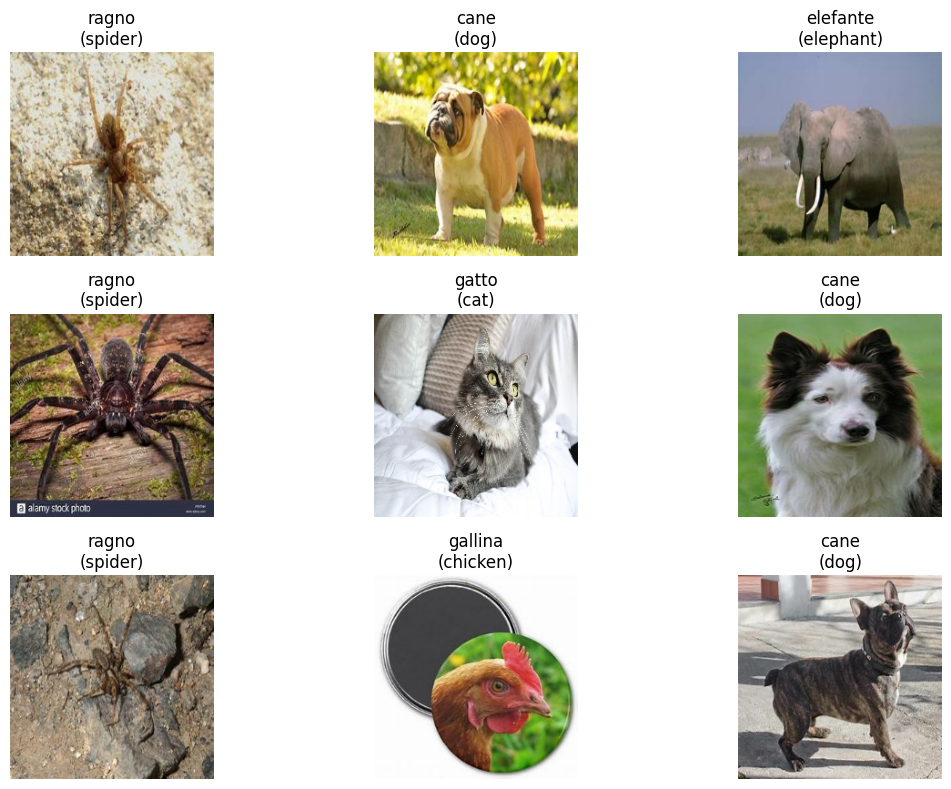

In [ ]:
# 7. VISUALISASI SAMPLE

plt.figure(figsize=(12, 8))
for images, labels in train_ds_raw.take(1):
    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        label_name = class_names[labels[i]]
        plt.title(f"{label_name}\n({translate.get(label_name, label_name)})")
        plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# 8. AUGMENTATION + PREPROCESS

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
    layers.RandomTranslation(0.1, 0.1)
])

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

def preprocess_train(x, y):
    x = tf.cast(x, tf.float32)
    x = data_augmentation(x, training=True)
    x = preprocess_input(x)
    return x, y

def preprocess_eval(x, y):
    x = tf.cast(x, tf.float32)
    x = preprocess_input(x)
    return x, y

train_ds = train_ds_raw.map(preprocess_train, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds = val_ds_raw.map(preprocess_eval, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds = test_ds_raw.map(preprocess_eval, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,593,610 (9.89 MB)

 Trainable params: 333,066 (1.27 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

Epoch 1/15
655/655 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.7969 - loss: 0.9086
Epoch 1: val_accuracy improved from None to 0.95103, saving model to /content/best_model_stage1.keras

Epoch 1: finished saving model to /content/best_model_stage1.keras

Validation accuracy mencapai 90.00%. Training dihentikan.
655/655 ━━━━━━━━━━━━━━━━━━━━ 338s 470ms/step - accuracy: 0.8511 - loss: 0.7199 - val_accuracy: 0.9510 - val_loss: 0.4108 - learning_rate: 0.0010
Epoch 2/25
655/655 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.8585 - loss: 0.6746
Epoch 2: val_accuracy improved from None to 0.95601, saving model to /content/best_model_finetune.keras

Epoch 2: finished saving model to /content/best_model_finetune.keras

Validation accuracy mencapai 90.00%. Training dihentikan.
655/655 ━━━━━━━━━━━━━━━━━━━━ 319s 452ms/step - accuracy: 0.8650 - loss: 0.6515 - val_accuracy: 0.9560 - val_loss: 0.3898 - learning_rate: 1.0000e-05
655/655 ━━━━━━━━━━━━━━━━━━━━ 282s 430ms/step - accuracy: 0.9254 - lo

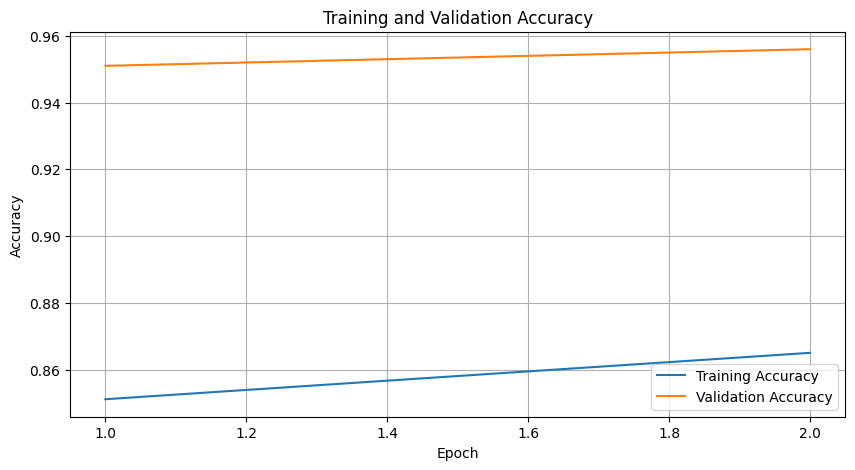

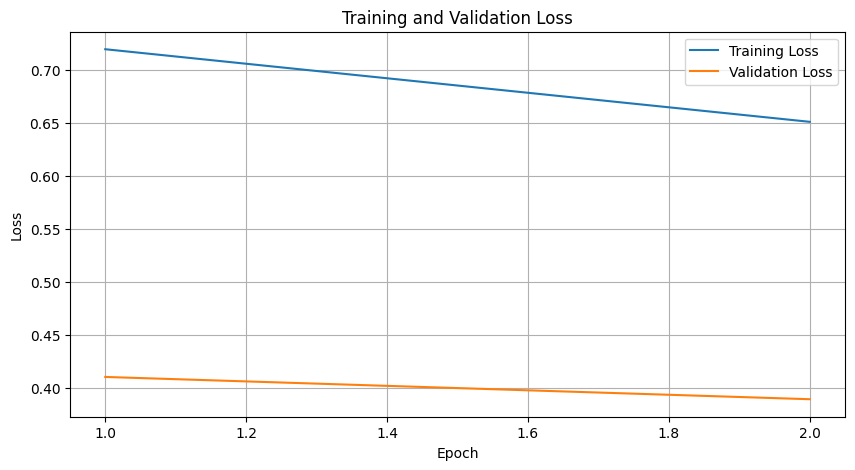

In [ ]:
# 9. MODEL

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet",
    pooling="avg"
)

base_model.trainable = False

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    base_model,
    layers.BatchNormalization(),
    layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(0.0005)),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


# 10. CALLBACKS

checkpoint_stage1_path = os.path.join(WORKING_DIR, "best_model_stage1.keras")
checkpoint_ft_path = os.path.join(WORKING_DIR, "best_model_finetune.keras")

early_stop = callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=6,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1
)

checkpoint_stage1 = callbacks.ModelCheckpoint(
    checkpoint_stage1_path,
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

class StopAtAccuracy(callbacks.Callback):
    def __init__(self, target=0.90):
        super().__init__()
        self.target = target

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_acc = logs.get("val_accuracy", 0)
        if val_acc >= self.target:
            print(f"\nValidation accuracy mencapai {self.target*100:.2f}%. Training dihentikan.")
            self.model.stop_training = True

stop_at_acc = StopAtAccuracy(target=0.90)


# 11. TRAINING STAGE 1

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop, reduce_lr, checkpoint_stage1, stop_at_acc]
)


# 12. FINE TUNING

base_model.trainable = True
fine_tune_at = 100

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

checkpoint_ft = callbacks.ModelCheckpoint(
    checkpoint_ft_path,
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    initial_epoch=len(history1.history["accuracy"]),
    callbacks=[early_stop, reduce_lr, checkpoint_ft, stop_at_acc]
)

# 13. EVALUASI
train_loss, train_acc = model.evaluate(train_ds, verbose=1)
val_loss, val_acc = model.evaluate(val_ds, verbose=1)
test_loss, test_acc = model.evaluate(test_ds, verbose=1)

print(f"Train Accuracy : {train_acc*100:.2f}%")
print(f"Val Accuracy   : {val_acc*100:.2f}%")
print(f"Test Accuracy  : {test_acc*100:.2f}%")

# 14. PLOT HISTORY

acc = history1.history["accuracy"] + history2.history["accuracy"]
val_acc_hist = history1.history["val_accuracy"] + history2.history["val_accuracy"]
loss = history1.history["loss"] + history2.history["loss"]
val_loss_hist = history1.history["val_loss"] + history2.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc_hist, label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss_hist, label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


Ground Truth : cane -> dog
Prediction   : cane -> dog
Confidence   : 0.998202919960022


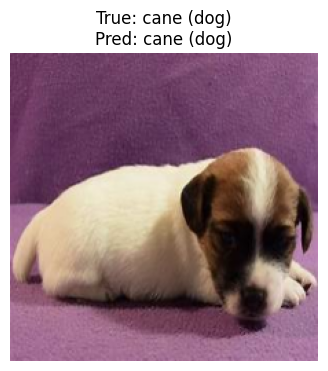

In [ ]:
# 15. TES SAMPLE DARI TEST SET

for test_images, test_labels in test_ds_raw.take(1):
    sample_img = test_images[0]
    sample_label = test_labels[0].numpy()
    break

sample_input = preprocess_input(tf.cast(tf.expand_dims(sample_img, axis=0), tf.float32))
pred = model.predict(sample_input, verbose=0)
pred_index = np.argmax(pred[0])

print("Ground Truth :", class_names[sample_label], "->", translate.get(class_names[sample_label], class_names[sample_label]))
print("Prediction   :", class_names[pred_index], "->", translate.get(class_names[pred_index], class_names[pred_index]))
print("Confidence   :", float(np.max(pred[0])))

plt.figure(figsize=(4, 4))
plt.imshow(sample_img.numpy().astype("uint8"))
plt.title(
    f"True: {class_names[sample_label]} ({translate.get(class_names[sample_label], class_names[sample_label])})\n"
    f"Pred: {class_names[pred_index]} ({translate.get(class_names[pred_index], class_names[pred_index])})"
)
plt.axis("off")
plt.show()


83/83 ━━━━━━━━━━━━━━━━━━━━ 13s 102ms/step
Akurasi test (manual): 95.74%
              precision    recall  f1-score   support

        cane       0.95      0.95      0.95       487
     cavallo       0.95      0.94      0.94       263
    elefante       0.99      0.96      0.98       146
    farfalla       0.98      0.96      0.97       212
     gallina       0.97      0.98      0.97       311
       gatto       0.97      0.92      0.95       168
       mucca       0.83      0.93      0.88       188
      pecora       0.96      0.90      0.93       182
       ragno       0.99      0.99      0.99       483
  scoiattolo       0.96      0.99      0.97       187

    accuracy                           0.96      2627
   macro avg       0.96      0.95      0.95      2627
weighted avg       0.96      0.96      0.96      2627



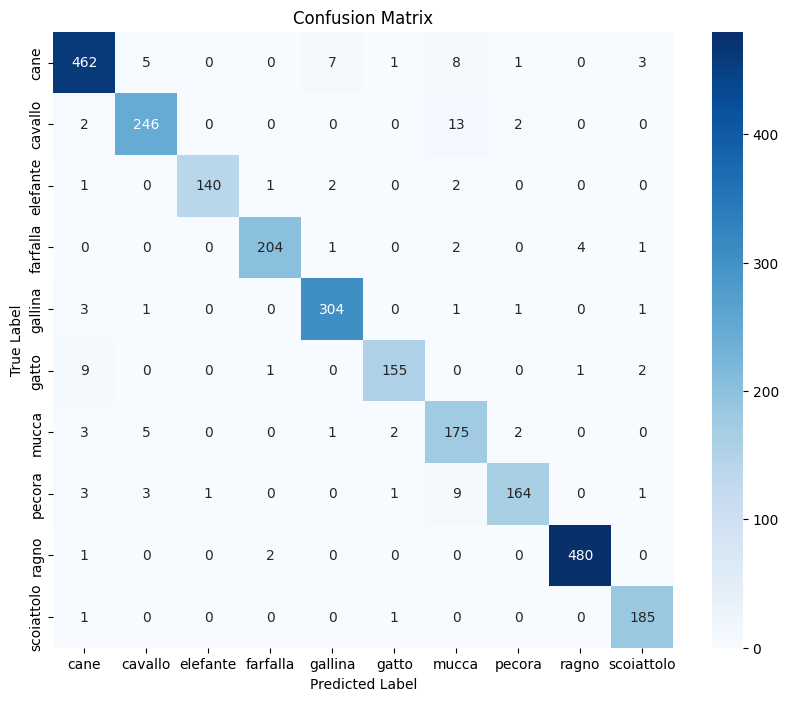

In [ ]:
# 16. CONFUSION MATRIX + REPORT

y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
y_pred_probs = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

test_acc_manual = accuracy_score(y_true, y_pred)
print(f"Akurasi test (manual): {test_acc_manual*100:.2f}%")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

Upload 1 gambar untuk prediksi opsional.


Saving cattt.jpg to cattt.jpg


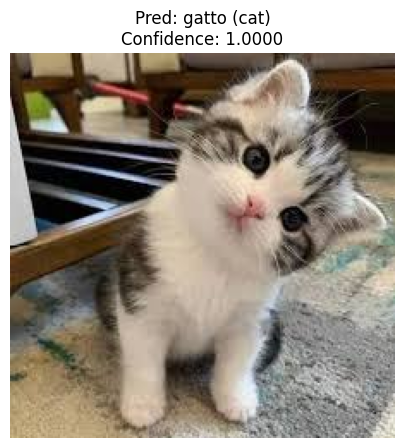

Prediction : gatto
English    : cat
Confidence : 0.9999951124191284


In [ ]:
# 17. PREDIKSI GAMBAR BARU

tflite_test_input = sample_input.numpy()

print("Upload 1 gambar untuk prediksi opsional.")
uploaded = colab_files.upload()

if len(uploaded) > 0:
    img_path = next(iter(uploaded.keys()))
    img = load_img(img_path, target_size=IMG_SIZE)
    img_array = img_to_array(img)
    img_input = preprocess_input(np.expand_dims(img_array.astype("float32"), axis=0))

    pred = model.predict(img_input, verbose=0)
    pred_idx = np.argmax(pred[0])
    confidence = float(np.max(pred[0]))

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(
        f"Pred: {class_names[pred_idx]} ({translate.get(class_names[pred_idx], class_names[pred_idx])})\n"
        f"Confidence: {confidence:.4f}"
    )
    plt.axis("off")
    plt.show()

    print("Prediction :", class_names[pred_idx])
    print("English    :", translate.get(class_names[pred_idx], class_names[pred_idx]))
    print("Confidence :", confidence)

    tflite_test_input = img_input
else:
    print("Tidak ada gambar di-upload. Uji TFLite akan memakai sample image dari test set.")


In [ ]:

# 18. FOLDER OUTPUT

TFLITE_DIR = os.path.join(SUBMISSION_DIR, "tflite")
os.makedirs(TFLITE_DIR, exist_ok=True)

#save fromat keras
KERAS_MODEL_PATH = os.path.join(SUBMISSION_DIR, "klasifikasi-hewan-10.keras")
model.save(KERAS_MODEL_PATH)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

TFLITE_MODEL_PATH = os.path.join(TFLITE_DIR, "model.tflite")
with open(TFLITE_MODEL_PATH, "wb") as f:
    f.write(tflite_model)

LABEL_PATH = os.path.join(TFLITE_DIR, "label.txt")
with open(LABEL_PATH, "w", encoding="utf-8") as f:
    for label in class_names:
        f.write(label + "\n")

print("Model KERAS dan TFLite berhasil disimpan.")
print("KERAS :", KERAS_MODEL_PATH)
print("TFLite:", TFLITE_MODEL_PATH)
print("Label :", LABEL_PATH)


# 20. UJI MODEL TFLITE

interpreter = tf.lite.Interpreter(model_path=TFLITE_MODEL_PATH)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

input_data = tflite_test_input.astype(input_details[0]["dtype"])
interpreter.set_tensor(input_details[0]["index"], input_data)
interpreter.invoke()

tflite_pred = interpreter.get_tensor(output_details[0]["index"])
tflite_pred_index = np.argmax(tflite_pred[0])

print("TFLite Prediction :", class_names[tflite_pred_index])
print("TFLite English    :", translate.get(class_names[tflite_pred_index], class_names[tflite_pred_index]))
print("TFLite Confidence :", float(np.max(tflite_pred[0])))


# 21. SIMPAN METADATA

training_config = {
    "dataset": "alessiocorrado99/animals10",
    "selected_classes": class_names,
    "selected_classes_english": [translate.get(c, c) for c in class_names],
    "img_size": list(IMG_SIZE),
    "batch_size": BATCH_SIZE,
    "seed": SEED,
    "num_classes": num_classes,
    "train_images": train_count,
    "val_images": val_count,
    "test_images": test_count,
    "train_accuracy": float(train_acc),
    "val_accuracy": float(val_acc),
    "test_accuracy": float(test_acc),
    "model": "MobileNetV2 + BatchNormalization + Dense(256) + Dropout",
    "preprocessing": "tf.keras.applications.mobilenet_v2.preprocess_input"
}

with open(os.path.join(SUBMISSION_DIR, "training_config.json"), "w", encoding="utf-8") as f:
    json.dump(training_config, f, indent=2, ensure_ascii=False)

readme_content = f"""# Image Classification Submission

## Nama Proyek
Klasifikasi Hewan Animals-10 (Semua Class)

## Dataset
alessiocorrado99/animals10

## Kelas yang dipakai
{", ".join(class_names)}

## Nama kelas (English)
{", ".join([translate.get(c, c) for c in class_names])}

## Arsitektur Model
MobileNetV2 + BatchNormalization + Dense(256) + Dropout

## Akurasi
- Train Accuracy  : {train_acc*100:.2f}%
- Val Accuracy    : {val_acc*100:.2f}%
- Test Accuracy   : {test_acc*100:.2f}%

## File Output
- klasifikasi-hewan-10.keras
- tflite/model.tflite
- tflite/label.txt
"""

with open(os.path.join(SUBMISSION_DIR, "README.md"), "w", encoding="utf-8") as f:
    f.write(readme_content)

requirements_content = """tensorflow
kagglehub
split-folders
numpy
matplotlib
scikit-learn
seaborn
"""

with open(os.path.join(SUBMISSION_DIR, "requirements.txt"), "w", encoding="utf-8") as f:
    f.write(requirements_content)


# 22. STRUKTUR FOLDER

for root, dirs, files in os.walk(SUBMISSION_DIR):
    level = root.replace(SUBMISSION_DIR, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 4 * (level + 1)
    for file in sorted(files):
        print(f"{subindent}{file}")

print("\nFolder submission tersimpan di:", SUBMISSION_DIR)


# 23. ZIP

zip_base = os.path.join(WORKING_DIR, "submission")
zip_path = shutil.make_archive(zip_base, "zip", SUBMISSION_DIR)
print("ZIP submission dibuat di:", zip_path)

colab_files.download(zip_path)

Saved artifact at '/tmp/tmp0z2m_3hz'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_161')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  137463482347024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137463482348368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137463482349328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137463482348944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137463482348176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137463482348560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137463482350864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137463482349904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137463482350288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137463482351440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137463482

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


ZIP submission dibuat di: /content/submission.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


=== UJI LOAD MODEL KERAS ===
Model berhasil di-load ulang.
Upload gambar baru untuk diuji:


Saving download (21).jpg to download (21).jpg


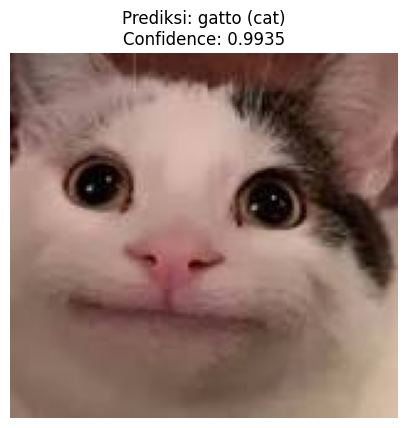

Path       : download (21).jpg
Prediction : gatto
English    : cat
Confidence : 0.9934853315353394
Probabilitas per kelas:
- cane         (dog       ): 0.0059
- cavallo      (horse     ): 0.0000
- elefante     (elephant  ): 0.0000
- farfalla     (butterfly ): 0.0000
- gallina      (chicken   ): 0.0000
- gatto        (cat       ): 0.9935
- mucca        (cow       ): 0.0000
- pecora       (sheep     ): 0.0000
- ragno        (spider    ): 0.0000
- scoiattolo   (squirrel  ): 0.0006


In [ ]:

# 24. LOAD MODEL KERAS UNTUK INFERENSI ULANG

print("\n=== UJI LOAD MODEL KERAS ===")
loaded_model = tf.keras.models.load_model(KERAS_MODEL_PATH)
print("Model berhasil di-load ulang.")

with open(LABEL_PATH, "r", encoding="utf-8") as f:
    loaded_class_names = [line.strip() for line in f if line.strip()]

def predict_image(img_path):
    img = load_img(img_path, target_size=IMG_SIZE)
    img_array = img_to_array(img).astype("float32")
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    pred = loaded_model.predict(img_array, verbose=0)
    pred_idx = np.argmax(pred[0])
    confidence = float(np.max(pred[0]))

    plt.figure(figsize=(5, 5))
    plt.imshow(load_img(img_path))
    plt.title(
        f"Prediksi: {loaded_class_names[pred_idx]} ({translate.get(loaded_class_names[pred_idx], loaded_class_names[pred_idx])})\n"
        f"Confidence: {confidence:.4f}"
    )
    plt.axis("off")
    plt.show()

    print("Path       :", img_path)
    print("Prediction :", loaded_class_names[pred_idx])
    print("English    :", translate.get(loaded_class_names[pred_idx], loaded_class_names[pred_idx]))
    print("Confidence :", confidence)
    print("Probabilitas per kelas:")
    for i, cls in enumerate(loaded_class_names):
        print(f"- {cls:12s} ({translate.get(cls, cls):10s}): {pred[0][i]:.4f}")

print("Upload gambar baru untuk diuji:")
uploaded = colab_files.upload()

if len(uploaded) > 0:
    img_path = next(iter(uploaded.keys()))
    predict_image(img_path)
else:
    print("Tidak ada file yang di-upload.")